## LSTM para Predição do Preço do Café Arábica (KC=F)
### Modelagem em log-retornos com validação temporal (walk-forward)

Este notebook implementa a camada de modelagem corrigida:
- **Alvo em log-retorno** (estacionário), não no nível bruto do preço, evitando a extrapolação fora de `[0,1]` que ocorre quando se escala o nível com `MinMaxScaler` ajustado no treino sob um split cronológico.
- **Scaler e seleção de features ajustados apenas no treino** de cada fold (sem vazamento).
- **Validação walk-forward** (janelas expansivas) em vez de um único split.
- **Baselines obrigatórios** (random walk, ARIMA) e **métricas além de RMSE** (MAE, sMAPE, MASE, acurácia direcional, Diebold-Mariano).

# 1. Imports e configuração

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


# 2. Carregamento e construção do alvo

In [2]:
df = pd.read_csv("data/dataset_final.csv", parse_dates=["date"]).sort_values("date").reset_index(drop=True)

# Alvo: log-retorno do preço de fechamento.
#   r_t = ln(P_t / P_{t-1})
# Estacionário, escala estável entre treino/val/teste, e simétrico para alta/baixa.
df["log_preco"]  = np.log(df["preco_cafe"])
df["ret_cafe"]   = df["log_preco"].diff()
df["ret_cambio"] = np.log(df["cambio_brl"]).diff()

df = df.dropna(subset=["ret_cafe", "ret_cambio"]).reset_index(drop=True)
print("Shape:", df.shape, "| período:", df["date"].min().date(), "->", df["date"].max().date())
print("ret_cafe — média {:.5f} | desvio {:.5f} | ADF-ready (estacionário)".format(
      df["ret_cafe"].mean(), df["ret_cafe"].std()))

Shape: (1762, 50) | período: 2019-01-02 -> 2025-12-30
ret_cafe — média 0.00070 | desvio 0.02261 | ADF-ready (estacionário)


## 2.1. Features derivadas (com embasamento)
Adicionamos features de mercado e agronômicas que capturam efeitos **não-lineares/cumulativos** que a correlação de Pearson não enxerga. A seleção fina é feita depois, **dentro do treino**.

In [3]:
# --- Mercado ---
df["vol_5"]  = df["ret_cafe"].rolling(5).std()     # volatilidade curta
df["vol_21"] = df["ret_cafe"].rolling(21).std()    # volatilidade ~mensal
df["sma_10"] = df["ret_cafe"].rolling(10).mean()

# --- Agronômicas regionais ---
# Risco de geada agregado (qualquer estação em risco) e intensidade máxima de frio.
geada_cols = [c for c in df.columns if c.startswith("geada_risco")]
frio_cols  = [c for c in df.columns if c.startswith("graus_frio")]
if geada_cols:
    df["geada_risco_any"] = df[geada_cols].max(axis=1)
    # janela de 30 dias: o impacto da geada na expectativa de oferta persiste
    df["geada_risco_30d"] = df["geada_risco_any"].rolling(30, min_periods=1).max()
if frio_cols:
    df["graus_frio_max"]  = df[frio_cols].max(axis=1)
    df["graus_frio_30d"]  = df["graus_frio_max"].rolling(30, min_periods=1).sum()

# Sazonalidade (floração set-out / colheita mai-set são fenologicamente sensíveis)
doy = df["date"].dt.dayofyear
df["sin_doy"] = np.sin(2*np.pi*doy/365.25)
df["cos_doy"] = np.cos(2*np.pi*doy/365.25)

df = df.dropna().reset_index(drop=True)
print("Após features derivadas:", df.shape)

Após features derivadas: (1742, 59)


# 3. Protocolo de janelamento e validação temporal

**Janelamento:** sequência de `LOOKBACK` dias de features → prevê o log-retorno do dia seguinte.

**Walk-forward (janela expansiva):** em vez de um único split 70/15/15, treinamos em `[0, t]`, validamos/testamos no bloco seguinte e avançamos. Cada fold ajusta seu **próprio scaler e seleção de features apenas no treino**. Entre treino e teste aplicamos um **embargo** de `LOOKBACK` dias para que nenhuma janela de teste contenha dias já vistos no treino (purga de leakage).

In [4]:
LOOKBACK = 45          # dias de histórico por amostra (hiperparâmetro)
HORIZON  = 1           # previsão 1 passo à frente
EMBARGO  = LOOKBACK    # gap treino/teste para evitar sobreposição de janelas
N_SPLITS = 5           # folds walk-forward

TARGET = "ret_cafe"
# Candidatas a feature (o alvo defasado entra como feature via janela)
feature_cols = [
    "ret_cafe", "ret_cambio", "vol_5", "vol_21", "sma_10",
    "sin_doy", "cos_doy",
] + [c for c in ["geada_risco_any","geada_risco_30d","graus_frio_max","graus_frio_30d"] if c in df.columns]
# Variáveis climáticas regionais brutas (temp min/média, umidade, precip, radiação)
feature_cols += [c for c in df.columns if c.startswith((
    "temp_min_C_min_","temp_ar_C_mean_","umidade_pct_mean_",
    "precip_mm_sum_","radiacao_kJm2_sum_"))]
feature_cols = list(dict.fromkeys(feature_cols))  # remove duplicatas mantendo ordem
print(f"{len(feature_cols)} features candidatas")

31 features candidatas


In [5]:
def make_windows(X, y, lookback, horizon=1):
    """X: (n, f) array já escalado; y: (n,) alvo. Retorna (janelas, alvos)."""
    Xs, ys = [], []
    for i in range(len(X) - lookback - horizon + 1):
        Xs.append(X[i:i+lookback])
        ys.append(y[i+lookback+horizon-1])
    return np.asarray(Xs, dtype=np.float32), np.asarray(ys, dtype=np.float32)


def walk_forward_indices(n, n_splits, min_train, embargo):
    """Gera (idx_treino, idx_teste) com janela de treino expansiva."""
    test_size = (n - min_train) // n_splits
    for k in range(n_splits):
        tr_end   = min_train + k * test_size
        te_start = tr_end + embargo
        te_end   = te_start + test_size if k < n_splits - 1 else n
        if te_start >= n:
            break
        yield np.arange(0, tr_end), np.arange(te_start, te_end)

# 4. Modelo LSTM

In [6]:
class LSTMRegressor(nn.Module):
    def __init__(self, n_features, hidden=48, n_layers=1, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, num_layers=n_layers,
                            batch_first=True,
                            dropout=dropout if n_layers > 1 else 0.0)
        self.drop = nn.Dropout(dropout)
        self.head = nn.Linear(hidden, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.drop(out[:, -1, :])   # último passo temporal
        return self.head(out).squeeze(-1)


def train_one(model, Xtr, ytr, Xva, yva, epochs=150, lr=1e-3, patience=15, batch=32):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    lossf = nn.MSELoss()
    Xtr_t = torch.tensor(Xtr).to(device); ytr_t = torch.tensor(ytr).to(device)
    Xva_t = torch.tensor(Xva).to(device); yva_t = torch.tensor(yva).to(device)
    best, best_state, wait = float("inf"), None, 0
    n = len(Xtr_t)
    for ep in range(epochs):
        model.train()
        perm = torch.randperm(n)
        for i in range(0, n, batch):
            idx = perm[i:i+batch]
            opt.zero_grad()
            loss = lossf(model(Xtr_t[idx]), ytr_t[idx])
            loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            vl = lossf(model(Xva_t), yva_t).item()
        if vl < best:
            best, best_state, wait = vl, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
        else:
            wait += 1
            if wait >= patience:
                break
    if best_state:
        model.load_state_dict(best_state)
    return model

# 5. Métricas (além de RMSE)

In [7]:
def smape(y, yhat):
    d = (np.abs(y) + np.abs(yhat))
    d[d == 0] = 1e-8
    return 100 * np.mean(2 * np.abs(yhat - y) / d)

def mase(y, yhat, y_train):
    # erro escalado pelo naive (random walk) no treino. < 1 => bate o baseline.
    naive = np.mean(np.abs(np.diff(y_train)))
    naive = naive if naive > 0 else 1e-8
    return mean_absolute_error(y, yhat) / naive

def directional_accuracy(y, yhat):
    return float(np.mean(np.sign(y) == np.sign(yhat)))

def diebold_mariano(y, p1, p2, h=1):
    # H0: mesma acurácia. d_t = e1^2 - e2^2 ; estatística ~ N(0,1)
    e1, e2 = (y - p1)**2, (y - p2)**2
    d = e1 - e2
    n = len(d); dbar = d.mean()
    gamma0 = np.mean((d - dbar)**2)
    var = gamma0 / n
    return float(dbar / np.sqrt(var)) if var > 0 else 0.0

# 6. Execução do walk-forward

Para cada fold: ajusta `StandardScaler` no treino → escala treino e teste → janela → treina LSTM (com early stopping sobre uma fatia interna de validação) → avalia contra o **random walk** (ŷ = 0 em log-retorno, i.e. preço de amanhã = preço de hoje).

In [8]:
MIN_TRAIN = int(len(df) * 0.5)
results = []
oos_pred, oos_true, oos_naive = [], [], []

for fold, (tr_idx, te_idx) in enumerate(walk_forward_indices(len(df), N_SPLITS, MIN_TRAIN, EMBARGO)):
    # validação interna = últimos 15% do treino (para early stopping)
    cut = int(len(tr_idx) * 0.85)
    tr_core, va_core = tr_idx[:cut], tr_idx[cut:]

    # Scaler ajustado SÓ no núcleo de treino
    scaler = StandardScaler().fit(df.loc[tr_core, feature_cols].values)
    def sc(idx): return scaler.transform(df.loc[idx, feature_cols].values)

    y_all = df[TARGET].values
    Xtr, ytr = make_windows(sc(tr_core), y_all[tr_core], LOOKBACK, HORIZON)
    Xva, yva = make_windows(sc(va_core), y_all[va_core], LOOKBACK, HORIZON)
    Xte, yte = make_windows(sc(te_idx),  y_all[te_idx],  LOOKBACK, HORIZON)
    if len(Xte) == 0 or len(Xtr) == 0:
        continue

    model = LSTMRegressor(n_features=len(feature_cols))
    model = train_one(model, Xtr, ytr, Xva, yva)

    model.eval()
    with torch.no_grad():
        pred = model(torch.tensor(Xte).to(device)).cpu().numpy()

    naive = np.zeros_like(yte)  # random walk em log-retorno

    rmse = np.sqrt(mean_squared_error(yte, pred))
    rmse_naive = np.sqrt(mean_squared_error(yte, naive))
    results.append({
        "fold": fold, "n_test": len(yte),
        "RMSE": rmse, "RMSE_naive": rmse_naive,
        "MAE": mean_absolute_error(yte, pred),
        "sMAPE": smape(yte, pred),
        "MASE": mase(yte, pred, y_all[tr_idx]),
        "DirAcc": directional_accuracy(yte, pred),
        "DM_vs_naive": diebold_mariano(yte, pred, naive),
    })
    oos_pred.extend(pred); oos_true.extend(yte); oos_naive.extend(naive)
    print(f"fold {fold}: RMSE {rmse:.5f} (naive {rmse_naive:.5f}) | "
          f"DirAcc {results[-1]['DirAcc']:.3f} | MASE {results[-1]['MASE']:.3f}")

res = pd.DataFrame(results)
print("\n=== Médias walk-forward ===")
print(res[["RMSE","RMSE_naive","MAE","sMAPE","MASE","DirAcc","DM_vs_naive"]].mean().round(4).to_string())

fold 0: RMSE 0.02275 (naive 0.02212) | DirAcc 0.434 | MASE 0.735
fold 1: RMSE 0.02325 (naive 0.02295) | DirAcc 0.473 | MASE 0.711
fold 2: RMSE 0.02443 (naive 0.02399) | DirAcc 0.481 | MASE 0.784
fold 3: RMSE 0.02218 (naive 0.02242) | DirAcc 0.566 | MASE 0.665
fold 4: RMSE 0.02520 (naive 0.02479) | DirAcc 0.565 | MASE 0.757

=== Médias walk-forward ===
RMSE             0.0236
RMSE_naive       0.0233
MAE              0.0183
sMAPE          160.1242
MASE             0.7304
DirAcc           0.5036
DM_vs_naive      0.5121


# 7. Leitura dos resultados

- **MASE < 1** e **RMSE < RMSE_naive** ⇒ o LSTM tem habilidade real além do random walk.
- **DM_vs_naive** com |valor| > 1,96 ⇒ a diferença é estatisticamente significativa (5%). **Atenção:** é comum o LSTM NÃO bater o random walk em log-retorno de preço diário — se for o caso, isso é um resultado honesto a reportar, não um fracasso. Documente.
- **DirAcc** próximo de 0,5 indica que acertar a direção do movimento é difícil (esperado em mercado eficiente).

Out-of-sample agregado:
  RMSE   : 0.02347
  Naive  : 0.02316
  DirAcc : 0.499
  DM     : 1.375


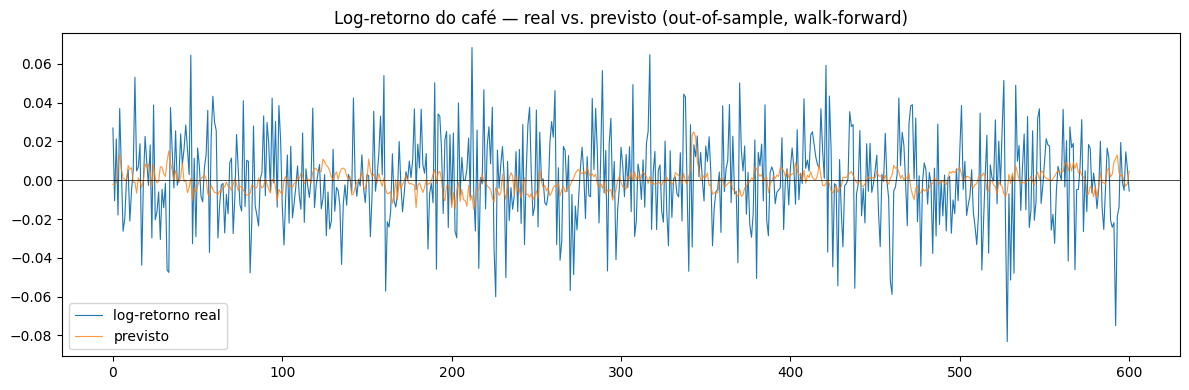

In [9]:
oos_true = np.array(oos_true); oos_pred = np.array(oos_pred)
print("Out-of-sample agregado:")
print(f"  RMSE   : {np.sqrt(mean_squared_error(oos_true, oos_pred)):.5f}")
print(f"  Naive  : {np.sqrt(mean_squared_error(oos_true, np.array(oos_naive))):.5f}")
print(f"  DirAcc : {directional_accuracy(oos_true, oos_pred):.3f}")
print(f"  DM     : {diebold_mariano(oos_true, oos_pred, np.array(oos_naive)):.3f}")

# Reconstrói preço (nível) a partir do log-retorno previsto, para visualização
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(oos_true, label="log-retorno real", lw=0.8)
ax.plot(oos_pred, label="previsto", lw=0.8, alpha=0.8)
ax.axhline(0, color="k", lw=0.5)
ax.set_title("Log-retorno do café — real vs. previsto (out-of-sample, walk-forward)")
ax.legend(); plt.tight_layout(); plt.show()

# 8. Próximos passos sugeridos
1. **Baseline ARIMA** (via `statsmodels`) sobre o log-retorno, comparado por Diebold-Mariano.
2. **Comparar Opção B vs Opção C** (clima agregado ponderado por produção) com este mesmo protocolo — vira resultado metodológico.
3. **Busca de hiperparâmetros** (`LOOKBACK`, `hidden`, `n_layers`, `dropout`) **dentro do treino** de cada fold.
4. **Seleção de features dentro do fold** (ex.: importância de Random Forest no treino) — ainda não aplicada aqui; todas as candidatas entram.